# Component 4 — Perceptual Survey Analysis

**Thesis:** Paralinguistic Features in Emotional Speech — Comparative Analysis of Human and AI-Generated Voice  
**n = 78 respondents** | 24 stimuli (12 human, 12 AI ElevenLabs) | RMS-normalized audio  

## Structure
- Cell 1: Quick Start (imports, mapping, helpers)
- Cell 2: Load & parse survey responses → long format
- Cell 3: Demographics
- Cell 4: H3 — Emotion recognition accuracy
- Cell 5: H3 Plot
- Cell 6: Confusion matrices
- Cell 7: H4 — Human/AI source detection stats
- Cell 8: H4 Plot
- Cell 9: Confidence analysis
- Cell 10: Per-stimulus accuracy table
- Cell 11: Key findings summary

In [2]:
# ── QUICK START ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import binomtest, pointbiserialr
import warnings, os
warnings.filterwarnings("ignore")

# Paths
BASE = os.path.dirname(os.path.abspath("survey_analysis.ipynb"))
SURVEY_CSV  = os.path.join(BASE, "Emotional Voice Perception Study_Submissions_2026-06-08.csv") 
MANIFEST    = os.path.join(BASE, "survey_files_v2.csv")

# Ground-truth mapping — exact order recordings were presented in Tally.so
# Part 1: 12 recordings (emotion recognition only, blind condition)
# Part 2: 12 recordings (emotion + human/AI source judgment)
MAPPING = pd.DataFrame([
    # slot, part, filename, source, voice/actor, gender, emotion
    dict(slot=1,  part=1, filename="S1_H_F_angry_kids",   source="human", voice="actor16", gender="F", emotion="angry"),
    dict(slot=2,  part=1, filename="S2_AI_M_neutral_kids",source="ai",    voice="ryan",    gender="M", emotion="neutral"),
    dict(slot=3,  part=1, filename="S1_H_M_sad_dogs",     source="human", voice="actor11", gender="M", emotion="sad"),
    dict(slot=4,  part=1, filename="S2_AI_F_happy_dogs",  source="ai",    voice="sarah",   gender="F", emotion="happy"),
    dict(slot=5,  part=1, filename="S1_H_F_disgust_dogs", source="human", voice="actor16", gender="F", emotion="disgust"),
    dict(slot=6,  part=1, filename="S2_AI_M_fearful_kids",source="ai",    voice="ryan",    gender="M", emotion="fearful"),
    dict(slot=7,  part=1, filename="S1_H_M_neutral_kids", source="human", voice="actor11", gender="M", emotion="neutral"),
    dict(slot=8,  part=1, filename="S2_AI_F_angry_kids",  source="ai",    voice="sarah",   gender="F", emotion="angry"),
    dict(slot=9,  part=1, filename="S1_H_F_happy_dogs",   source="human", voice="actor16", gender="F", emotion="happy"),
    dict(slot=10, part=1, filename="S2_AI_M_sad_dogs",    source="ai",    voice="ryan",    gender="M", emotion="sad"),
    dict(slot=11, part=1, filename="S1_H_M_fearful_kids", source="human", voice="actor11", gender="M", emotion="fearful"),
    dict(slot=12, part=1, filename="S2_AI_F_disgust_dogs",source="ai",    voice="sarah",   gender="F", emotion="disgust"),
    dict(slot=13, part=2, filename="S3_H_M_happy_dogs",   source="human", voice="actor11", gender="M", emotion="happy"),
    dict(slot=14, part=2, filename="S3_AI_F_neutral_kids",source="ai",    voice="sarah",   gender="F", emotion="neutral"),
    dict(slot=15, part=2, filename="S3_H_F_sad_dogs",     source="human", voice="actor16", gender="F", emotion="sad"),
    dict(slot=16, part=2, filename="S3_AI_M_angry_kids",  source="ai",    voice="ryan",    gender="M", emotion="angry"),
    dict(slot=17, part=2, filename="S3_H_M_angry_kids",   source="human", voice="actor11", gender="M", emotion="angry"),
    dict(slot=18, part=2, filename="S3_AI_F_sad_dogs",    source="ai",    voice="sarah",   gender="F", emotion="sad"),
    dict(slot=19, part=2, filename="S3_H_F_neutral_kids", source="human", voice="actor16", gender="F", emotion="neutral"),
    dict(slot=20, part=2, filename="S3_AI_M_happy_dogs",  source="ai",    voice="ryan",    gender="M", emotion="happy"),
    dict(slot=21, part=2, filename="S3_H_M_disgust_dogs", source="human", voice="actor11", gender="M", emotion="disgust"),
    dict(slot=22, part=2, filename="S3_AI_F_fearful_kids",source="ai",    voice="sarah",   gender="F", emotion="fearful"),
    dict(slot=23, part=2, filename="S3_H_F_fearful_kids", source="human", voice="actor16", gender="F", emotion="fearful"),
    dict(slot=24, part=2, filename="S3_AI_M_disgust_dogs",source="ai",    voice="ryan",    gender="M", emotion="disgust"),
])

EMOTIONS = ["angry", "disgust", "fearful", "happy", "neutral", "sad"]
EMO_COLORS = dict(angry="#e74c3c", disgust="#8e44ad", fearful="#e67e22",
                  happy="#f1c40f", neutral="#95a5a6", sad="#3498db")

# ── HELPER FUNCTIONS ─────────────────────────────────────────────────────────
import re

def norm_emotion(x):
    """Normalize bilingual emotion label to lowercase English key."""
    if pd.isna(x): return None
    s = str(x).split("/")[0].strip().lower()
    lookup = {"angry":"angry","disgust":"disgust","neutral":"neutral",
              "happy":"happy","sad":"sad","fearful":"fearful"}
    return lookup.get(s, s)

def norm_hai(x):
    """Normalize human/AI judgment label."""
    if pd.isna(x): return None
    s = str(x).lower()
    if "human" in s or "ludzki" in s: return "human"
    if "ai" in s or "wygenerowany" in s: return "ai"
    return "notsure"

def cnum_key(c):
    m = re.search(r"\((\d+)\)$", c); return int(m.group(1)) if m else 1

print("Quick Start loaded. n_stimuli =", len(MAPPING))


Quick Start loaded. n_stimuli = 24


In [3]:
# ── CELL 2: LOAD & PARSE SURVEY RESPONSES ───────────────────────────────────
df_raw = pd.read_csv(SURVEY_CSV)
# Drop header-repeat row if present
df_raw = df_raw[df_raw["Submission ID"] != "Submission ID"].copy()
N = len(df_raw)
print(f"Respondents: {N}")

# Identify column groups
p1_emo_cols  = sorted([c for c in df_raw.columns if re.match(r"^\d+\. What emotion.*(?<!\(2\))$", c)],
                       key=lambda c: int(re.match(r"^(\d+)\.", c).group(1)))
p2_emo_cols  = sorted([c for c in df_raw.columns if re.match(r"^\d+\. What emotion.*\(2\)$", c)],
                       key=cnum_key)
all_conf_cols = sorted([c for c in df_raw.columns if "How confident" in c], key=cnum_key)
p1_conf_cols  = all_conf_cols[:12]
p2_conf_cols  = all_conf_cols[12:24]
hai_cols      = sorted([c for c in df_raw.columns if c.startswith("Do you think this voice")], key=cnum_key)
hai_conf_cols = sorted([c for c in df_raw.columns if "human/AI judgment" in c], key=cnum_key)

print(f"P1 emotion cols: {len(p1_emo_cols)} | P2 emotion cols: {len(p2_emo_cols)}")
print(f"HAI judgment cols: {len(hai_cols)}")

# Build long-format table: one row per respondent x recording
rows = []
for _, resp in df_raw.iterrows():
    rid = resp["Submission ID"]
    for i, col in enumerate(p1_emo_cols):
        rows.append(dict(respondent=rid, slot=i+1,
            emo_answer=norm_emotion(resp[col]),
            emo_conf=pd.to_numeric(resp[p1_conf_cols[i]], errors="coerce"),
            hai_answer=None, hai_conf=None))
    for i, col in enumerate(p2_emo_cols):
        rows.append(dict(respondent=rid, slot=i+13,
            emo_answer=norm_emotion(resp[col]),
            emo_conf=pd.to_numeric(resp[p2_conf_cols[i]], errors="coerce"),
            hai_answer=norm_hai(resp[hai_cols[i]]) if i < len(hai_cols) else None,
            hai_conf=pd.to_numeric(resp[hai_conf_cols[i]], errors="coerce") if i < len(hai_conf_cols) else None))

long = pd.DataFrame(rows).merge(MAPPING, on="slot", how="left")
long["emo_correct"] = long["emo_answer"] == long["emotion"]
long["hai_correct"] = long.apply(
    lambda r: (r["hai_answer"] == r["source"])
              if r["hai_answer"] not in [None, "notsure"] else None, axis=1)

print(f"Long format: {len(long)} rows (= {N} respondents x 24 stimuli)")
print(f"Null emo_answer: {long['emo_answer'].isna().sum()}")


Respondents: 78
P1 emotion cols: 12 | P2 emotion cols: 12
HAI judgment cols: 12
Long format: 1872 rows (= 78 respondents x 24 stimuli)
Null emo_answer: 0


In [4]:
# ── CELL 3: DEMOGRAPHICS ─────────────────────────────────────────────────────
demo_cols = {
    "Age": "What is your age group?\n(Jaka jest Twoja grupa wiekowa?)",
    "Gender": "What is your gender?\n(Jaka jest Twoja plec?)",
    "English": "How well do you understand spoken English?\n(Jak dobrze rozumiesz mowiony angielski?)",
    "Device": "What device are you using to listen?\n(Jakiego urzadzenia uzywasz do sluchania?)",
}

print(f"Total respondents: {N}\n")
for label, col in demo_cols.items():
    # fuzzy match column
    matched = [c for c in df_raw.columns if label.lower() in c.lower() or
               (label == "Age" and "age" in c.lower()) or
               (label == "Gender" and "gender" in c.lower()) or
               (label == "English" and "english" in c.lower()) or
               (label == "Device" and "device" in c.lower())]
    if matched:
        print(f"{label}:")
        print(df_raw[matched[0]].value_counts(dropna=False).to_string())
        print()


Total respondents: 78

Age:
What is your age group?\n(Jaka jest Twoja grupa wiekowa?)
18-24    32
45-54    21
25-34     8
55+       7
35-44     4
15        2
16        1
17        1
78        1
67        1

Gender:
What is your gender?\n(Jaka jest Twoja płeć?)
Female / Kobieta                      42
Male / Mężczyzna                      34
Non-binary / Niebinarne                1
Prefer not to say / Wolę nie mówić     1

English:
How well do you understand spoken English?\n(Jak dobrze rozumiesz mówiony angielski?)
Fluent / Biegły                    48
Basic / Podstawowy                 15
Intermediate / Komunikatywny       13
Native speaker / Język ojczysty     2

Device:
What device are you using to listen?\n(Jakiego urządzenia używasz do słuchania?)
Speakers / Głośniki               34
Earbuds / Słuchawki douszne       22
Headphones / Słuchawki nauszne    18
Głośnik telefonu                   1
Phone                              1
Telephone                          1
Phone speaker  

In [5]:
# ── CELL 4: H3 — EMOTION RECOGNITION ACCURACY ───────────────────────────────
overall_acc  = long["emo_correct"].mean() * 100
human_acc    = long[long["source"]=="human"]["emo_correct"].mean() * 100
ai_acc       = long[long["source"]=="ai"]["emo_correct"].mean() * 100

print(f"OVERALL EMOTION RECOGNITION ACCURACY (human perceivers, n={N})")
print(f"  Overall (24 stimuli):  {overall_acc:.1f}%")
print(f"  Human stimuli:         {human_acc:.1f}%")
print(f"  AI stimuli:            {ai_acc:.1f}%")

print("\nPER-EMOTION ACCURACY BY SOURCE:")
print(f"  {'Emotion':10} {'Human stim':>12}  {'AI stim':>12}")
emo_results = {}
for e in EMOTIONS:
    h_acc = long[(long["emotion"]==e) & (long["source"]=="human")]["emo_correct"].mean() * 100
    a_acc = long[(long["emotion"]==e) & (long["source"]=="ai")]["emo_correct"].mean() * 100
    emo_results[e] = {"human": h_acc, "ai": a_acc}
    print(f"  {e:10}  {h_acc:8.1f}%     {a_acc:8.1f}%")
emo_df = pd.DataFrame(emo_results).T

print("\nH3 COMPARISON — HUMAN PERCEIVERS vs AI DETECTORS:")
print(f"  {'Agent':22}  {'Human stim':>11}  {'AI stim':>10}")
print(f"  {'Human perceivers':22}  {human_acc:>9.1f}%  {ai_acc:>9.1f}%")
print(f"  {'Hume AI':22}  {42.0:>9.1f}%  {29.2:>9.1f}%")
print(f"  {'SpeechBrain wav2vec2':22}  {42.9:>9.1f}%  {35.6:>9.1f}%")


OVERALL EMOTION RECOGNITION ACCURACY (human perceivers, n=78)
  Overall (24 stimuli):  49.7%
  Human stimuli:         51.4%
  AI stimuli:            48.1%

PER-EMOTION ACCURACY BY SOURCE:
  Emotion      Human stim       AI stim
  angry           59.0%         58.3%
  disgust         46.8%         17.3%
  fearful         94.9%         43.6%
  happy            7.1%         37.8%
  neutral         59.0%         92.3%
  sad             41.7%         39.1%

H3 COMPARISON — HUMAN PERCEIVERS vs AI DETECTORS:
  Agent                    Human stim     AI stim
  Human perceivers             51.4%       48.1%
  Hume AI                      42.0%       29.2%
  SpeechBrain wav2vec2         42.9%       35.6%


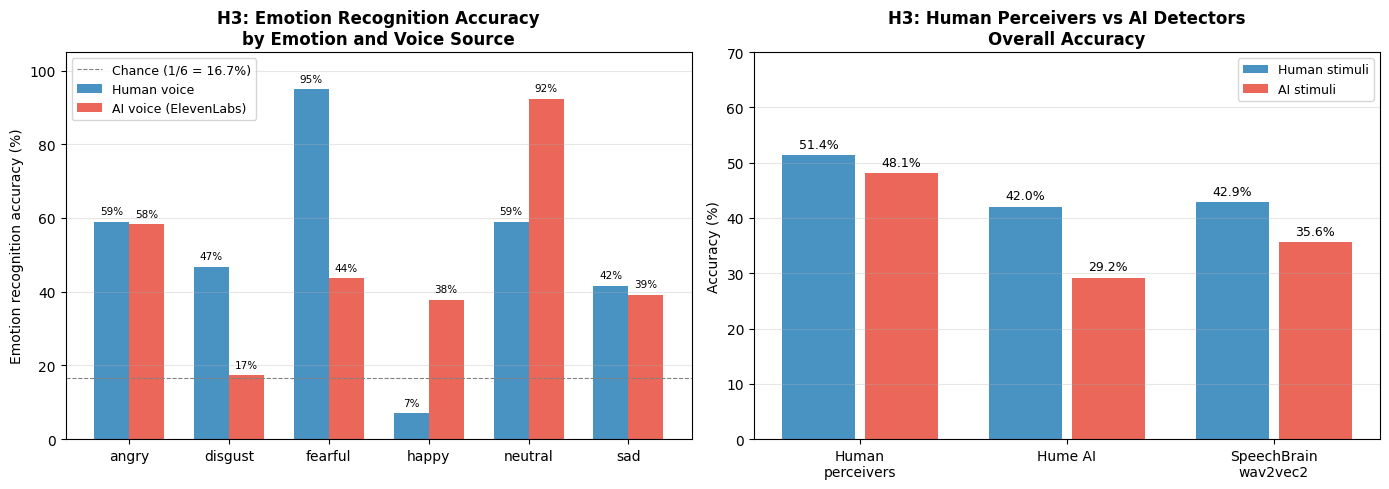

Saved: component4_H3_accuracy.png


In [6]:
# ── CELL 5: H3 PLOT — Emotion accuracy by emotion x source ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: human vs AI accuracy per emotion (grouped bar)
ax = axes[0]
x = np.arange(len(EMOTIONS))
w = 0.35
bars_h = ax.bar(x - w/2, [emo_df.loc[e,"human"] for e in EMOTIONS], w,
                label="Human voice", color="#2980b9", alpha=0.85)
bars_a = ax.bar(x + w/2, [emo_df.loc[e,"ai"] for e in EMOTIONS], w,
                label="AI voice (ElevenLabs)", color="#e74c3c", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(EMOTIONS, fontsize=10)
ax.set_ylabel("Emotion recognition accuracy (%)")
ax.set_title("H3: Emotion Recognition Accuracy\nby Emotion and Voice Source", fontweight="bold")
ax.set_ylim(0, 105)
ax.axhline(16.7, color="gray", linestyle="--", linewidth=0.8, label="Chance (1/6 = 16.7%)")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
for bar in list(bars_h) + list(bars_a):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=7.5)

# Right: Agent comparison (overall human vs AI stim)
ax2 = axes[1]
agents = ["Human\nperceivers", "Hume AI", "SpeechBrain\nwav2vec2"]
h_vals = [human_acc, 42.0, 42.9]
a_vals = [ai_acc,    29.2, 35.6]
x2 = np.arange(len(agents))
b1 = ax2.bar(x2 - 0.2, h_vals, 0.35, label="Human stimuli", color="#2980b9", alpha=0.85)
b2 = ax2.bar(x2 + 0.2, a_vals, 0.35, label="AI stimuli", color="#e74c3c", alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(agents, fontsize=10)
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("H3: Human Perceivers vs AI Detectors\nOverall Accuracy", fontweight="bold")
ax2.set_ylim(0, 70)
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.3)
for bar in list(b1) + list(b2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(r"plots_component4/component4_H3_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: component4_H3_accuracy.png")


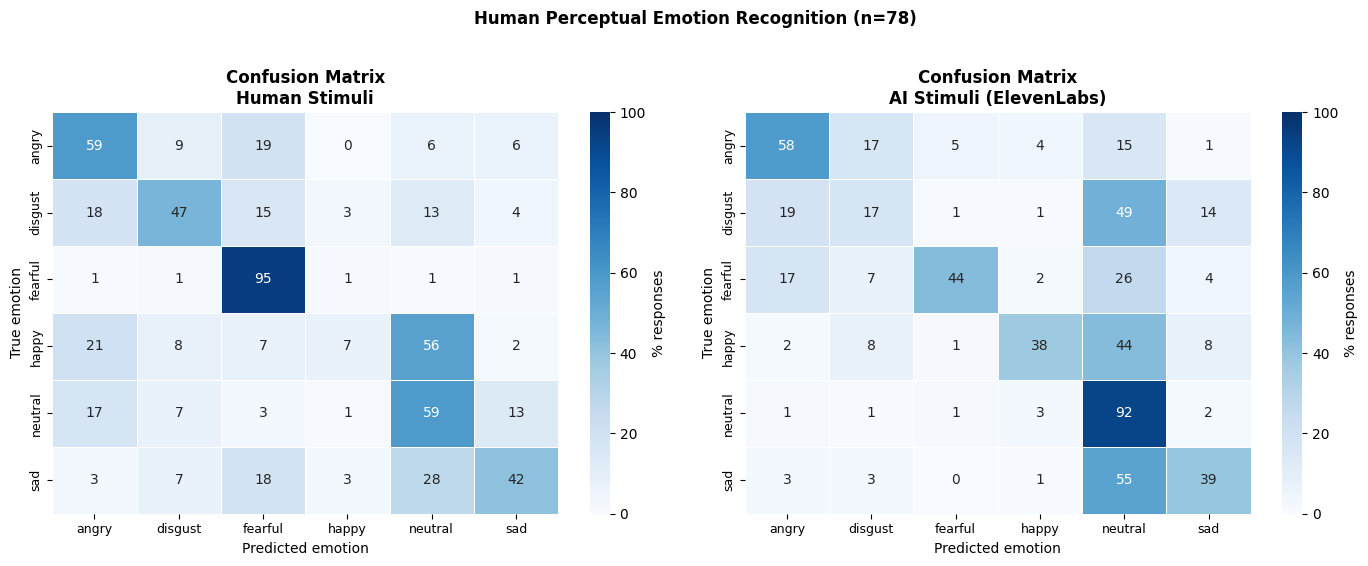

Saved: component4_confusion_matrices.png


In [7]:
# ── CELL 6: CONFUSION MATRICES ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, subset_label, subset_source in [(axes[0], "Human Stimuli", "human"),
                                         (axes[1], "AI Stimuli (ElevenLabs)", "ai")]:
    sub = long[long["source"]==subset_source]
    ct  = pd.crosstab(sub["emotion"], sub["emo_answer"], normalize="index") * 100
    ct  = ct.reindex(index=EMOTIONS, columns=EMOTIONS, fill_value=0)

    mask_diag = np.eye(len(EMOTIONS), dtype=bool)
    sns.heatmap(ct, ax=ax, annot=True, fmt=".0f", cmap="Blues",
                vmin=0, vmax=100, linewidths=0.5,
                xticklabels=EMOTIONS, yticklabels=EMOTIONS,
                cbar_kws={"label": "% responses"})
    ax.set_title(f"Confusion Matrix\n{subset_label}", fontweight="bold")
    ax.set_xlabel("Predicted emotion"); ax.set_ylabel("True emotion")
    ax.tick_params(labelsize=9)

plt.suptitle("Human Perceptual Emotion Recognition (n=78)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(r"plots_component4/component4_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: component4_confusion_matrices.png")


In [8]:
# ── CELL 7: H4 — HUMAN/AI SOURCE DETECTION ──────────────────────────────────
p2 = long[long["part"]==2].copy()

# Counts
total_judgments  = p2["hai_answer"].notna().sum()
notsure_count    = (p2["hai_answer"]=="notsure").sum()
definitive       = p2[p2["hai_answer"].isin(["human","ai"])]
n_def_correct    = int(definitive["hai_correct"].sum())
n_def_total      = len(definitive)
acc_def          = n_def_correct / n_def_total * 100
notsure_rate     = notsure_count / total_judgments * 100

# Inclusive (not-sure = wrong)
n_all_correct    = int((p2["hai_answer"]==p2["source"]).sum())
acc_incl         = n_all_correct / len(p2) * 100

# Binomial tests
btest_def  = binomtest(n_def_correct, n_def_total, 0.5, alternative="greater")
btest_incl = binomtest(n_all_correct, len(p2), 0.5, alternative="greater")

print(f"H4: HUMAN/AI SOURCE DETECTION (Part 2, n={N})")
print(f"  Total judgments: {total_judgments}")
print(f"  Definitive answers (human/ai): {n_def_total} | Not-sure: {notsure_count} ({notsure_rate:.1f}%)")
print(f"\n  Accuracy (definitive only): {n_def_correct}/{n_def_total} = {acc_def:.1f}%")
print(f"  Binomial test vs 50% chance: p={btest_def.pvalue:.6f}  (*** < 0.001)")
print(f"\n  Accuracy (inclusive, not-sure=wrong): {n_all_correct}/{len(p2)} = {acc_incl:.1f}%")
print(f"  Binomial test vs 50% chance: p={btest_incl.pvalue:.4f}")

print("\n  Human stimuli correctly identified as human:", end=" ")
h_def = definitive[definitive["source"]=="human"]
print(f"{int(h_def['hai_correct'].sum())}/{len(h_def)} = {h_def['hai_correct'].mean()*100:.1f}%")

print("  AI stimuli correctly identified as AI:", end=" ")
a_def = definitive[definitive["source"]=="ai"]
print(f"{int(a_def['hai_correct'].sum())}/{len(a_def)} = {a_def['hai_correct'].mean()*100:.1f}%")

print("\n  Per-voice AI detection rate (Part 2, definitive only):")
for v, grp in definitive[definitive["source"]=="ai"].groupby("voice"):
    print(f"    {v:10}: {grp['hai_correct'].mean()*100:.1f}% ({int(grp['hai_correct'].sum())}/{len(grp)})")

print("\n  Note: Ryan Euclidean distance from human centroid = 2.79; Sarah = 2.72")
print("  (From survey_prep selection analysis — lower = more acoustically similar to human)")


H4: HUMAN/AI SOURCE DETECTION (Part 2, n=78)
  Total judgments: 936
  Definitive answers (human/ai): 795 | Not-sure: 141 (15.1%)

  Accuracy (definitive only): 532/795 = 66.9%
  Binomial test vs 50% chance: p=0.000000  (*** < 0.001)

  Accuracy (inclusive, not-sure=wrong): 532/936 = 56.8%
  Binomial test vs 50% chance: p=0.0000

  Human stimuli correctly identified as human: 272/405 = 67.2%
  AI stimuli correctly identified as AI: 260/390 = 66.7%

  Per-voice AI detection rate (Part 2, definitive only):
    ryan      : 61.5% (120/195)
    sarah     : 71.8% (140/195)

  Note: Ryan Euclidean distance from human centroid = 2.79; Sarah = 2.72
  (From survey_prep selection analysis — lower = more acoustically similar to human)


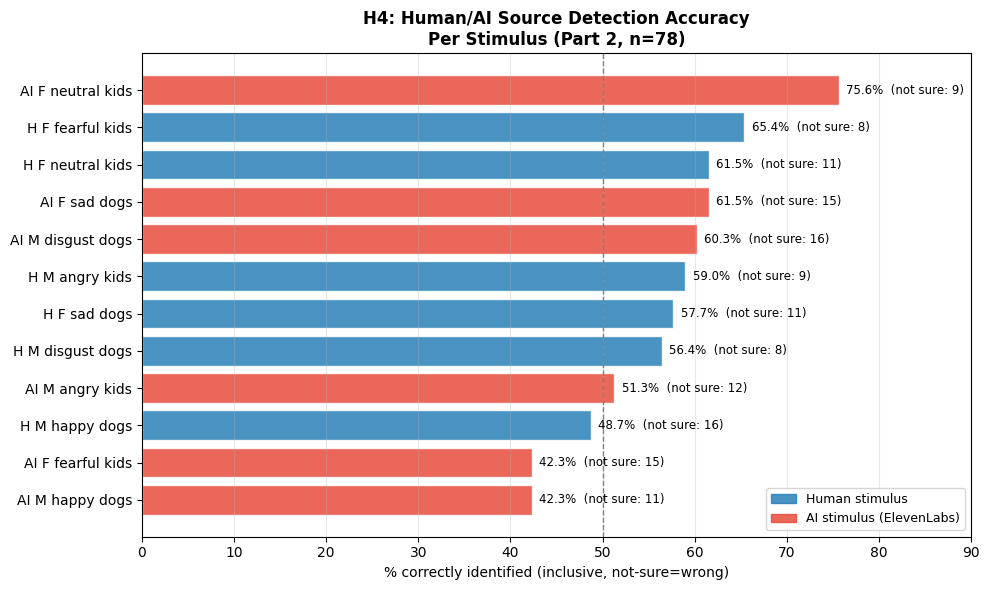

Saved: component4_H4_source_detection.png


In [9]:
# ── CELL 8: H4 PLOT — Per-stimulus source detection ─────────────────────────
per_stim = []
for _, row in MAPPING[MAPPING["part"]==2].iterrows():
    sl   = row["slot"]
    sub  = p2[p2["slot"]==sl]
    def_ = sub[sub["hai_answer"].isin(["human","ai"])]
    ns   = (sub["hai_answer"]=="notsure").sum()
    n_corr = (sub["hai_answer"]==row["source"]).sum()
    acc    = n_corr / len(sub) * 100  # inclusive
    per_stim.append(dict(slot=sl, label=row["filename"].replace("S3_","").replace("_"," "),
                         source=row["source"], emotion=row["emotion"], acc=acc, notsure=int(ns)))
per_stim_df = pd.DataFrame(per_stim).sort_values("acc", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2980b9" if s=="human" else "#e74c3c" for s in per_stim_df["source"]]
bars = ax.barh(per_stim_df["label"], per_stim_df["acc"], color=colors, alpha=0.85, edgecolor="white")
ax.axvline(50, color="gray", linestyle="--", linewidth=1, label="Chance (50%)")

for i, (bar, row) in enumerate(zip(bars, per_stim_df.itertuples())):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            f"{row.acc:.1f}%  (not sure: {row.notsure})",
            va="center", fontsize=8.5)

blue_patch = mpatches.Patch(color="#2980b9", alpha=0.85, label="Human stimulus")
red_patch  = mpatches.Patch(color="#e74c3c", alpha=0.85, label="AI stimulus (ElevenLabs)")
ax.legend(handles=[blue_patch, red_patch], loc="lower right", fontsize=9)
ax.set_xlabel("% correctly identified (inclusive, not-sure=wrong)")
ax.set_title("H4: Human/AI Source Detection Accuracy\nPer Stimulus (Part 2, n=78)", fontweight="bold")
ax.set_xlim(0, 90)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(r"plots_component4/component4_H4_source_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: component4_H4_source_detection.png")


In [10]:
# ── CELL 9: CONFIDENCE ANALYSIS ──────────────────────────────────────────────
long["emo_conf"] = pd.to_numeric(long["emo_conf"], errors="coerce")

conf_correct   = long[long["emo_correct"]==True]["emo_conf"].mean()
conf_incorrect = long[long["emo_correct"]==False]["emo_conf"].mean()

vals = long.dropna(subset=["emo_conf","emo_correct"])
r_conf, p_conf = pointbiserialr(vals["emo_correct"].astype(int), vals["emo_conf"])

print("CONFIDENCE ANALYSIS")
print(f"  Overall mean confidence:         {long['emo_conf'].mean():.2f} / 5  (median={long['emo_conf'].median():.0f})")
print(f"  Confidence when correct:         {conf_correct:.2f}")
print(f"  Confidence when incorrect:       {conf_incorrect:.2f}")
print(f"  Point-biserial r:                {r_conf:.3f}  (p={p_conf:.4f})")
print(f"  Interpretation: {'No significant confidence-accuracy correlation.' if p_conf > 0.05 else 'Significant correlation found.'}")

# Confidence by emotion
print("\n  Mean confidence per true emotion:")
for e in EMOTIONS:
    sub = long[long["emotion"]==e]["emo_conf"]
    print(f"    {e:10}: {sub.mean():.2f}  (n={sub.count()})")


CONFIDENCE ANALYSIS
  Overall mean confidence:         3.91 / 5  (median=4)
  Confidence when correct:         3.91
  Confidence when incorrect:       3.90
  Point-biserial r:                0.007  (p=0.7747)
  Interpretation: No significant confidence-accuracy correlation.

  Mean confidence per true emotion:
    angry     : 3.87  (n=312)
    disgust   : 4.05  (n=312)
    fearful   : 3.79  (n=312)
    happy     : 3.99  (n=312)
    neutral   : 3.83  (n=312)
    sad       : 3.92  (n=312)


In [11]:
# ── CELL 10: PER-STIMULUS ACCURACY TABLE ─────────────────────────────────────
print(f"{'Slot':>4}  {'Filename':30}  {'Src':5}  {'Emo':8}  {'%Correct':>9}  {'Modal Answer':>13}  {'N correct':>9}")
print("-" * 95)
for slot in range(1, 25):
    sub = long[long["slot"]==slot]
    fname  = sub["filename"].iloc[0]
    src    = sub["source"].iloc[0]
    emo    = sub["emotion"].iloc[0]
    pct    = sub["emo_correct"].mean() * 100
    vc     = sub["emo_answer"].value_counts()
    modal  = vc.index[0] if len(vc) else "?"
    n_corr = int(sub["emo_correct"].sum())
    n_tot  = len(sub)
    flag   = " *" if modal != emo else "  "
    print(f"  {slot:2d}  {fname:30}  {src:5}  {emo:8}  {pct:7.1f}%  {modal:13}{flag}  {n_corr:4}/{n_tot}")
print("\n  * = modal answer differs from true emotion")


Slot  Filename                        Src    Emo        %Correct   Modal Answer  N correct
-----------------------------------------------------------------------------------------------
   1  S1_H_F_angry_kids               human  angry        89.7%  angry              70/78
   2  S2_AI_M_neutral_kids            ai     neutral      93.6%  neutral            73/78
   3  S1_H_M_sad_dogs                 human  sad          64.1%  sad                50/78
   4  S2_AI_F_happy_dogs              ai     happy        10.3%  neutral       *     8/78
   5  S1_H_F_disgust_dogs             human  disgust      46.2%  disgust            36/78
   6  S2_AI_M_fearful_kids            ai     fearful      16.7%  neutral       *    13/78
   7  S1_H_M_neutral_kids             human  neutral      69.2%  neutral            54/78
   8  S2_AI_F_angry_kids              ai     angry        65.4%  angry              51/78
   9  S1_H_F_happy_dogs               human  happy         6.4%  angry         *     5/78
  1

In [13]:
# ── CELL 11b: NEUTRAL COLLAPSE — AI SAD (for Section 4.5) ───────────────────
# This computes the exact % of AI sad responses heard as neutral by human listeners.
# Companion to the Hume neutral bias analysis in component3_h2_analysis.ipynb.

# AI sad stimuli in survey:
#   slot 10 = S2_AI_M_sad_dogs (Ryan, Part 1, index 9 in p1 emotion cols)
#   slot 18 = S3_AI_F_sad_dogs (Sarah, Part 2, index 5 in p2 emotion cols)

ai_sad_ryan  = long[long['slot'] == 10]['emo_answer']
ai_sad_sarah = long[long['slot'] == 18]['emo_answer']
ai_sad_all   = pd.concat([ai_sad_ryan, ai_sad_sarah])

total       = ai_sad_all.notna().sum()
as_neutral  = (ai_sad_all == 'neutral').sum()
as_sad      = (ai_sad_all == 'sad').sum()

print('NEUTRAL COLLAPSE — AI SAD (human listener responses)')
print(f'  AI sad stimuli: Ryan (slot 10) + Sarah (slot 18), n={N} respondents each')
print(f'  Total responses: {total}')
print(f'  Heard as NEUTRAL: {as_neutral} ({as_neutral/total*100:.1f}%)')
print(f'  Heard correctly as SAD: {as_sad} ({as_sad/total*100:.1f}%)')
print(f'  Full distribution: {ai_sad_all.value_counts().to_dict()}')
print()
print('  Per stimulus:')
for label, s in [('Ryan M sad (slot 10)', ai_sad_ryan), ('Sarah F sad (slot 18)', ai_sad_sarah)]:
    t = s.notna().sum()
    n_n = (s == 'neutral').sum()
    n_s = (s == 'sad').sum()
    print(f'    {label}: neutral={n_n}/{t} ({n_n/t*100:.1f}%)  sad={n_s}/{t} ({n_s/t*100:.1f}%)')
print()
print('CROSS-COMPONENT NOTE:')
print('  Hume classified 80.0% of AI sad files as neutral (see component3_h2_analysis.ipynb).')
print(f'  Human listeners classified {as_neutral/total*100:.1f}% of AI sad as neutral.')
print('  Both independent methods converge: AI sad collapses toward neutral.')

NEUTRAL COLLAPSE — AI SAD (human listener responses)
  AI sad stimuli: Ryan (slot 10) + Sarah (slot 18), n=78 respondents each
  Total responses: 156
  Heard as NEUTRAL: 86 (55.1%)
  Heard correctly as SAD: 61 (39.1%)
  Full distribution: {'neutral': 86, 'sad': 61, 'angry': 4, 'disgust': 4, 'happy': 1}

  Per stimulus:
    Ryan M sad (slot 10): neutral=40/78 (51.3%)  sad=32/78 (41.0%)
    Sarah F sad (slot 18): neutral=46/78 (59.0%)  sad=29/78 (37.2%)

CROSS-COMPONENT NOTE:
  Hume classified 80.0% of AI sad files as neutral (see component3_h2_analysis.ipynb).
  Human listeners classified 55.1% of AI sad as neutral.
  Both independent methods converge: AI sad collapses toward neutral.


In [18]:
# ── CELL 12: KEY FINDINGS SUMMARY (fully dynamic) ───────────────────────────
print("=" * 65)
print("COMPONENT 4 — KEY FINDINGS SUMMARY")
print("=" * 65)
print()
print(f"Sample: n={N}, mean confidence={long['emo_conf'].mean():.2f}/5")
print()

# Emotion recognition
overall_acc = long["emo_correct"].mean() * 100
h_acc = long[long["source"]=="human"]["emo_correct"].mean() * 100
a_acc = long[long["source"]=="ai"]["emo_correct"].mean() * 100
print("EMOTION RECOGNITION:")
print(f"  Overall accuracy:         {overall_acc:.1f}%  (chance = 16.7%)")
print(f"  Human stimuli:            {h_acc:.1f}%")
print(f"  AI stimuli:               {a_acc:.1f}%")
print()

# H3 comparison
print("H3 HUMAN vs AI DETECTORS:")
print(f"  Humans vs Hume on human stim:       {h_acc:.1f}% vs 42.0%  ({h_acc-42.0:+.1f} pp)")
print(f"  Humans vs SpeechBrain on human stim:{h_acc:.1f}% vs 42.9%  ({h_acc-42.9:+.1f} pp)")
print(f"  Humans vs Hume on AI stim:          {a_acc:.1f}% vs 29.2%  ({a_acc-29.2:+.1f} pp)")
print(f"  Humans vs SpeechBrain on AI stim:   {a_acc:.1f}% vs 35.6%  ({a_acc-35.6:+.1f} pp)")
print()

# H4 source detection
p2 = long[long["part"]==2]
def_ = p2[p2["hai_answer"].isin(["human","ai"])]
n_corr   = int((p2["hai_answer"]==p2["source"]).sum())
acc_incl = n_corr / len(p2) * 100
n_def    = len(def_); n_def_c = int(def_["hai_correct"].sum())
acc_def  = n_def_c / n_def * 100
ns       = (p2["hai_answer"]=="notsure").sum()
bt = binomtest(n_def_c, n_def, 0.5, alternative="greater")
print("H4 SOURCE DETECTION:")
print(f"  Accuracy (definitive):    {acc_def:.1f}%  ({n_def_c}/{n_def})")
print(f"  Accuracy (inclusive):     {acc_incl:.1f}%  ({n_corr}/{len(p2)})")
print(f"  Binomial test vs 50%:     p={bt.pvalue:.6f}  (*** p < 0.001)")
print(f"  Not-sure rate:            {ns/len(p2)*100:.1f}%  ({ns} of {len(p2)})")
print()

# Per-emotion breakdown table
EMOTIONS = ["angry","disgust","fearful","happy","neutral","sad"]
print("PER-EMOTION ACCURACY (human vs AI stimuli):")
print(f"  {'Emotion':10}  {'Human stim':>12}  {'AI stim':>12}")
for e in EMOTIONS:
    ha = long[(long["emotion"]==e)&(long["source"]=="human")]["emo_correct"].mean()*100
    aa = long[(long["emotion"]==e)&(long["source"]=="ai")]["emo_correct"].mean()*100
    print(f"  {e:10}  {ha:10.1f}%  {aa:10.1f}%")
print()

# Dynamic per-stimulus highlights
per_stim = []
for slot in range(1, 25):
    sub = long[long["slot"]==slot]
    per_stim.append({"slot":slot, "fname":sub["filename"].iloc[0],
                     "src":sub["source"].iloc[0], "emo":sub["emotion"].iloc[0],
                     "pct":sub["emo_correct"].mean()*100})
df_ps = pd.DataFrame(per_stim)

p2_ai_ps = []
for slot in range(13, 25):
    sub = p2[p2["slot"]==slot]
    src = sub["source"].iloc[0]
    emo = sub["emotion"].iloc[0]
    fname = sub["filename"].iloc[0]
    n_det = (sub["hai_answer"]==src).sum()
    total = sub["hai_answer"].notna().sum()
    p2_ai_ps.append({"slot":slot,"fname":fname,"src":src,"emo":emo,
                     "pct_det": n_det/total*100 if total>0 else float("nan"),
                     "notsure": (sub["hai_answer"]=="notsure").sum()})
df_p2 = pd.DataFrame(p2_ai_ps)
ai_p2  = df_p2[df_p2["src"]=="ai"]

worst  = df_ps.nsmallest(1,"pct").iloc[0]
best   = df_ps.nlargest(1,"pct").iloc[0]
h_easy = ai_p2.nlargest(1,"pct_det").iloc[0]
# h_hard = ai_p2.nsmallest(1,"pct_det").iloc[0]
min_det = ai_p2["pct_det"].min()
hardest = ai_p2[ai_p2["pct_det"] == min_det]

print("NOTABLE PER-STIMULUS FINDINGS:")
print(f"  Hardest emotion to recognize: {worst['fname']} = {worst['pct']:.1f}%  (true: {worst['emo']})")
print(f"  Best recognized:              {best['fname']} = {best['pct']:.1f}%")
# print(f"  AI easiest to detect as AI:   {h_easy['fname']} = {h_easy['pct_det']:.1f}%")
# print(f"  AI hardest to detect as AI:   {h_hard['fname']} = {h_hard['pct_det']:.1f}%  (passes as human)")
print(f"  AI hardest to detect as AI ({min_det:.1f}%):")
for _, row in hardest.iterrows():
    print(f"    {row['fname']}  ({row['emo']})")
print()

# Confidence calibration
print("CONFIDENCE ANALYSIS:")
conf_corr   = long[long["emo_correct"]==True]["emo_conf"].mean()
conf_incorr = long[long["emo_correct"]==False]["emo_conf"].mean()
print(f"  Confidence correct:   {conf_corr:.2f}")
print(f"  Confidence incorrect: {conf_incorr:.2f}")
from scipy.stats import pointbiserialr
vals = long.dropna(subset=["emo_conf","emo_correct"])
r_v, p_v = pointbiserialr(vals["emo_correct"].astype(int), vals["emo_conf"])
print(f"  Point-biserial r={r_v:.3f}  p={p_v:.4f}  ({'no calibration' if p_v>0.05 else 'significant'})")


COMPONENT 4 — KEY FINDINGS SUMMARY

Sample: n=78, mean confidence=3.91/5

EMOTION RECOGNITION:
  Overall accuracy:         49.7%  (chance = 16.7%)
  Human stimuli:            51.4%
  AI stimuli:               48.1%

H3 HUMAN vs AI DETECTORS:
  Humans vs Hume on human stim:       51.4% vs 42.0%  (+9.4 pp)
  Humans vs SpeechBrain on human stim:51.4% vs 42.9%  (+8.5 pp)
  Humans vs Hume on AI stim:          48.1% vs 29.2%  (+18.9 pp)
  Humans vs SpeechBrain on AI stim:   48.1% vs 35.6%  (+12.5 pp)

H4 SOURCE DETECTION:
  Accuracy (definitive):    66.9%  (532/795)
  Accuracy (inclusive):     56.8%  (532/936)
  Binomial test vs 50%:     p=0.000000  (*** p < 0.001)
  Not-sure rate:            15.1%  (141 of 936)

PER-EMOTION ACCURACY (human vs AI stimuli):
  Emotion       Human stim       AI stim
  angry             59.0%        58.3%
  disgust           46.8%        17.3%
  fearful           94.9%        43.6%
  happy              7.1%        37.8%
  neutral           59.0%        92.3%
  s